In [4]:
from pathlib import Path
from sklearn.metrics import silhouette_score
from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import math

In [5]:
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_PATH = DATA_DIR / "images.jpeg"

assert IMAGE_PATH.exists(), (
    f"Image not found at {IMAGE_PATH.resolve()}. "
    "Put an image in the data/ folder or update IMAGE_PATH."
)


In [6]:
random_state = 42

Size: (161, 161), Format: None, Mode: RGB


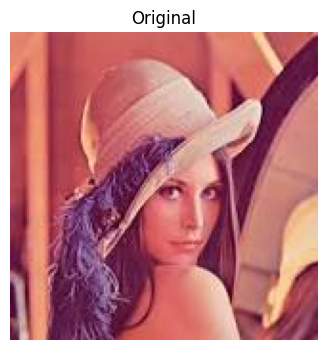

In [7]:
img = Image.open(IMAGE_PATH).convert("RGB")

print(f"Size: {img.size}, Format: {img.format}, Mode: {img.mode}")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Original")
plt.show()


As K-means uses distance, we need to normalize the data.

In [8]:
def compress_image(img_input, n_colors_input):
  image_array_local = np.array(img_input)
  h, w, c = image_array_local.shape
  pixels = image_array_local.reshape(-1, c).astype(np.float64) / 255.0

  kmeans = KMeans(n_clusters=n_colors_input, random_state=random_state, n_init=10)
  kmeans.fit(pixels)
  labels = kmeans.labels_

  palette = kmeans.cluster_centers_
  # Scale back to 0-255 before converting to uint8 for proper image display
  compressed = (palette[labels] * 255).reshape(h, w, c).astype(np.uint8)

  return compressed, kmeans


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

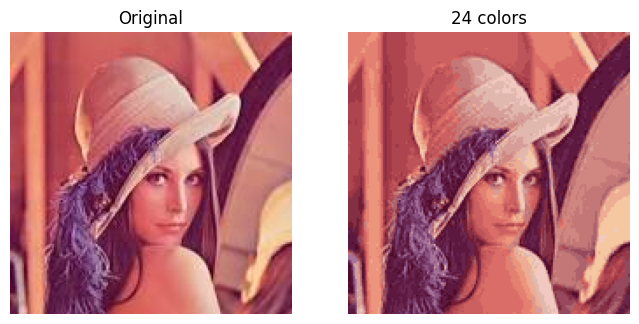

In [9]:
image_array = np.array(img)

compressed_24, kmeans_24 = compress_image(img, n_colors_input=24)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(compressed_24)
axes[1].set_title("24 colors")
axes[1].axis("off")
plt.show()

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

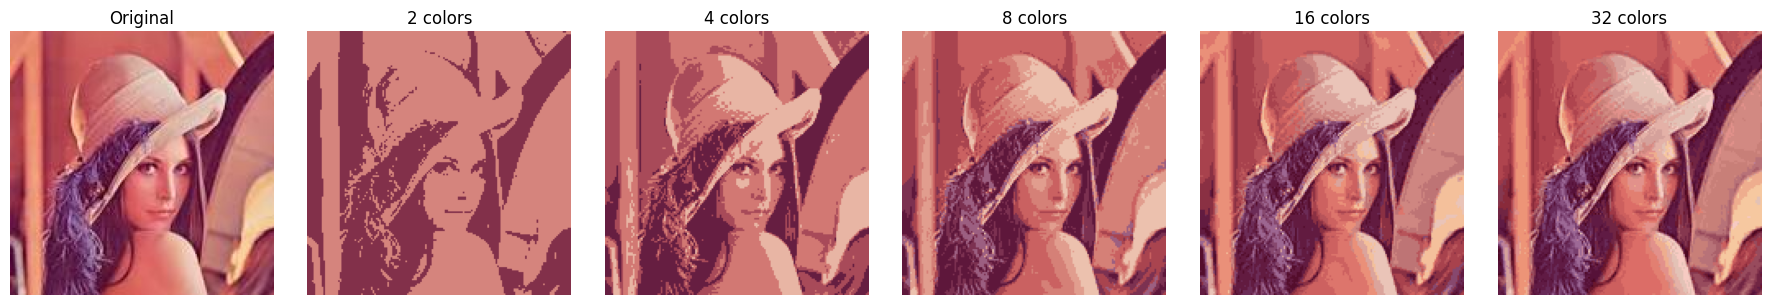

In [10]:
k_values = [2, 4, 8, 16, 32]
results = {}

fig, axes = plt.subplots(1, len(k_values) + 1, figsize=(3 * (len(k_values) + 1), 3))

axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, k in zip(axes[1:], k_values):
    compressed_k, model = compress_image(img, n_colors_input=k)
    output_image = Image.fromarray(compressed_k)
    output_path = OUTPUT_DIR / f"compressed_{k}_colors.png"
    output_image.save(output_path)
    results[k] = {"image": compressed_k, "model": model}
    ax.imshow(compressed_k)
    ax.set_title(f"{k} colors")
    ax.axis("off")

plt.tight_layout()
plt.show()

**Inertia** measures how close the data points are to the center of their assigned cluster.

**Silhouette score** shows how pixels closer to their own cluster than to other clusters?

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:2

k= 2  silhouette=0.527
k= 4  silhouette=0.469
k= 8  silhouette=0.378
k=16  silhouette=0.338
k=32  silhouette=0.319


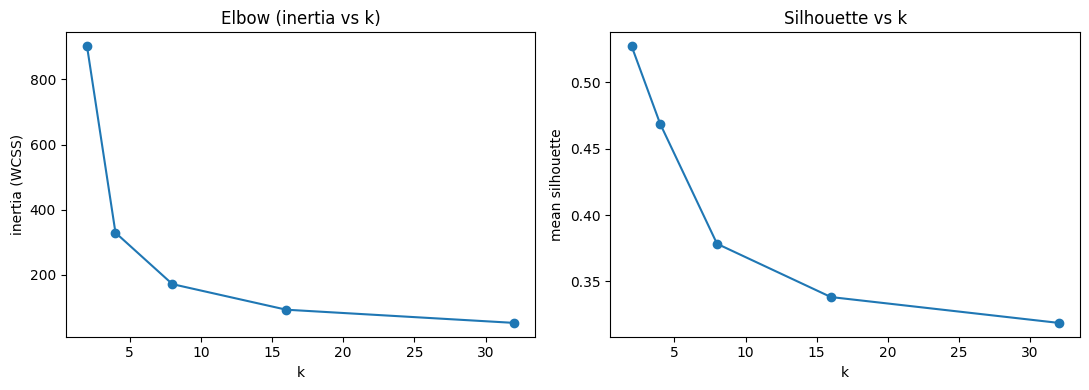

In [11]:
image_array_flat = np.array(img).reshape(-1, 3).astype(np.float64) / 255.0

inertias = [results[k]["model"].inertia_ for k in k_values]
sil_scores = [
    silhouette_score(image_array_flat, results[k]["model"].labels_, sample_size=min(len(image_array_flat), 3000), random_state=random_state)
    for k in k_values
]

for k, sil in zip(k_values, sil_scores):
    print(f"k={k:>2}  silhouette={sil:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(k_values, inertias, marker="o")
ax[0].set(title="Elbow (inertia vs k)", xlabel="k", ylabel="inertia (WCSS)")
ax[1].plot(k_values, sil_scores, marker="o")
ax[1].set(title="Silhouette vs k", xlabel="k", ylabel="mean silhouette")
plt.tight_layout()
plt.show()

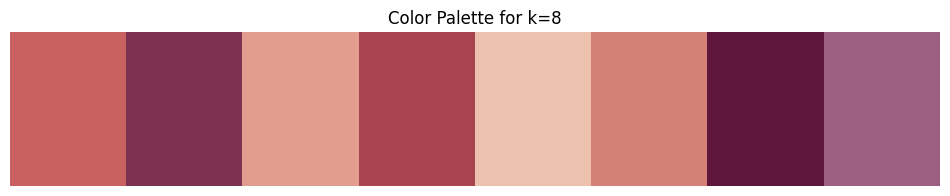

In [12]:
chosen_k = 8

if chosen_k in results:
    palette = results[chosen_k]['model'].cluster_centers_
else:
    kmeans_chosen = KMeans(n_clusters=chosen_k, random_state=random_state, n_init=10)
    kmeans_chosen.fit(image_array_flat)
    palette = kmeans_chosen.cluster_centers_

colors_display = (palette * 255).astype(np.uint8)

plt.figure(figsize=(chosen_k * 1.5, 2))
plt.imshow([colors_display], aspect='auto')
plt.title(f'Color Palette for k={chosen_k}')
plt.axis('off')
plt.show()

8 bits per channel * 3 channels (RGB)

Palette storage: k * 3 bytes (for R, G, B components)

Index storage: ceil(log2 k) bits per pixel

In [13]:
h, w, c = np.array(img).shape
original_bits_per_pixel = 8 * 3
original_total_bits = h * w * original_bits_per_pixel

palette_bytes = chosen_k * 3
palette_bits = palette_bytes * 8

index_bits_per_pixel = math.ceil(math.log2(chosen_k))
index_total_bits = h * w * index_bits_per_pixel

compressed_total_bits = palette_bits + index_total_bits

compression_ratio_per_pixel = original_bits_per_pixel / index_bits_per_pixel
overall_compression_ratio = original_total_bits / compressed_total_bits

print(f"Original image: {h}x{w} pixels, {original_bits_per_pixel} bits/pixel")
print(f"Total original bits: {original_total_bits:,}")
print(f"\nCompressed image with k={chosen_k}:")
print(f"  Palette storage: {palette_bytes} bytes ({palette_bits} bits)")
print(f"  Index storage: {index_bits_per_pixel} bits/pixel")
print(f"  Total index bits: {index_total_bits:,}")
print(f"Total compressed bits (palette + indices): {compressed_total_bits:,}")
print(f"\nCompression Ratio (bits/pixel): {compression_ratio_per_pixel:.2f}x (original {original_bits_per_pixel} / index {index_bits_per_pixel})")
print(f"Overall Compression Ratio (total bits): {overall_compression_ratio:.2f}x")

Original image: 161x161 pixels, 24 bits/pixel
Total original bits: 622,104

Compressed image with k=8:
  Palette storage: 24 bytes (192 bits)
  Index storage: 3 bits/pixel
  Total index bits: 77,763
Total compressed bits (palette + indices): 77,955

Compression Ratio (bits/pixel): 8.00x (original 24 / index 3)
Overall Compression Ratio (total bits): 7.98x


In [14]:
original_image_array = np.array(img)
original_pixels_scaled = original_image_array.astype(np.float64) / 255.0

mse_scores = {}
for k in k_values:
    compressed_image_array = results[k]['image']
    compressed_pixels_scaled = compressed_image_array.astype(np.float64) / 255.0

    mse = mean_squared_error(original_pixels_scaled.reshape(-1, 3), compressed_pixels_scaled.reshape(-1, 3))
    mse_scores[k] = mse
    print(f"k={k:>2}  MSE={mse:.6f}")


k= 2  MSE=0.011609
k= 4  MSE=0.004239
k= 8  MSE=0.002210
k=16  MSE=0.001201
k=32  MSE=0.000679


DBSCAN Compression (RGB)

Unlike K-Means, DBSCAN does not require the number of clusters to be specified beforehand. Instead, it relies on two parameters: eps (epsilon) and min_samples (minimum number of samples in a neighborhood).

In [15]:
from sklearn.cluster import DBSCAN

In [16]:
def compress_image_dbscan(img_input, eps_input, min_samples_input):
  image_array_local = np.array(img_input)
  h, w, c = image_array_local.shape
  pixels = image_array_local.reshape(-1, c).astype(np.float64) / 255.0

  dbscan = DBSCAN(eps=eps_input, min_samples=min_samples_input)
  dbscan.fit(pixels)
  labels = dbscan.labels_

  unique_labels = set(labels)
  n_clusters_ = len(unique_labels) - (1 if -1 in labels else 0)
  print(f"DBSCAN found {n_clusters_} clusters.")

  compressed_pixels = np.zeros_like(pixels)
  if n_clusters_ > 0:
    cluster_centers = np.array([pixels[labels == i].mean(axis=0) for i in range(n_clusters_)])

    for i in range(n_clusters_):
      compressed_pixels[labels == i] = cluster_centers[i]

    if -1 in labels:
      noise_indices = (labels == -1)
      if n_clusters_ > 0: 
          from sklearn.neighbors import NearestNeighbors
          nn = NearestNeighbors(n_neighbors=1).fit(cluster_centers)
          distances, indices = nn.kneighbors(pixels[noise_indices])
          compressed_pixels[noise_indices] = cluster_centers[indices.flatten()]
      else:
          compressed_pixels[noise_indices] = np.array([0.0, 0.0, 0.0])
  else:
      compressed_pixels = np.array([0.5, 0.5, 0.5])

  compressed = (compressed_pixels * 255).reshape(h, w, c).astype(np.uint8)

  return compressed, labels

In [17]:
eps_values = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06]
min_samples_values = [6, 12, 15]

dbscan_all_results_list = []

for eps in eps_values:
    for min_samples in min_samples_values:

        print(f"\nRunning DBSCAN with eps={eps}, min_samples={min_samples}")

        compressed_img, labels = compress_image_dbscan(
            img,
            eps_input=eps,
            min_samples_input=min_samples
        )

        unique_labels = set(labels)

        num_clusters = len(unique_labels) - (1 if -1 in labels else 0)

        num_noise_points = list(labels).count(-1) if -1 in labels else 0

        dbscan_all_results_list.append({
            "eps": eps,
            "min_samples": min_samples,
            "compressed_image": compressed_img,
            "labels": labels,
            "num_clusters": num_clusters,
            "num_noise_points": num_noise_points
        })

        print(f"  Found {num_clusters} distinct color clusters (excluding noise).")
        print(f"  Number of noise points: {num_noise_points}")


print("\n--- DBSCAN Parameter Comparison Summary ---")

print(f"{'Eps':<8}{'Min_Samples':<12}{'Clusters':<10}{'Noise Points':<15}")
print(f"{'='*8}{'='*12}{'='*10}{'='*15}")

for result in dbscan_all_results_list:
    print(
        f"{result['eps']:<8.3f}"
        f"{result['min_samples']:<12}"
        f"{result['num_clusters']:<10}"
        f"{result['num_noise_points']:<15}"
    )


Running DBSCAN with eps=0.005, min_samples=6
DBSCAN found 403 clusters.
  Found 403 distinct color clusters (excluding noise).
  Number of noise points: 22200

Running DBSCAN with eps=0.005, min_samples=12
DBSCAN found 64 clusters.
  Found 64 distinct color clusters (excluding noise).
  Number of noise points: 24749

Running DBSCAN with eps=0.005, min_samples=15
DBSCAN found 37 clusters.
  Found 37 distinct color clusters (excluding noise).
  Number of noise points: 25098

Running DBSCAN with eps=0.01, min_samples=6
DBSCAN found 175 clusters.
  Found 175 distinct color clusters (excluding noise).
  Number of noise points: 6367

Running DBSCAN with eps=0.01, min_samples=12
DBSCAN found 53 clusters.
  Found 53 distinct color clusters (excluding noise).
  Number of noise points: 11137

Running DBSCAN with eps=0.01, min_samples=15
DBSCAN found 50 clusters.
  Found 50 distinct color clusters (excluding noise).
  Number of noise points: 12781

Running DBSCAN with eps=0.02, min_samples=6
DBS

Testing on other image

In [18]:
IMAGE_PATH = DATA_DIR / "saryan_mountains.jpg"

Size: (605, 600), Format: None, Mode: RGB


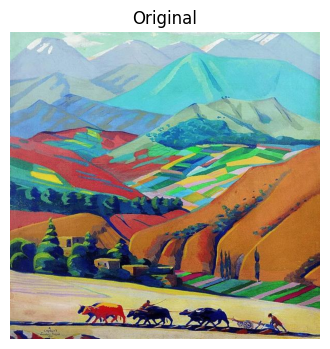

In [19]:
img = Image.open(IMAGE_PATH).convert("RGB")

print(f"Size: {img.size}, Format: {img.format}, Mode: {img.mode}")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Original")
plt.show()

/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_

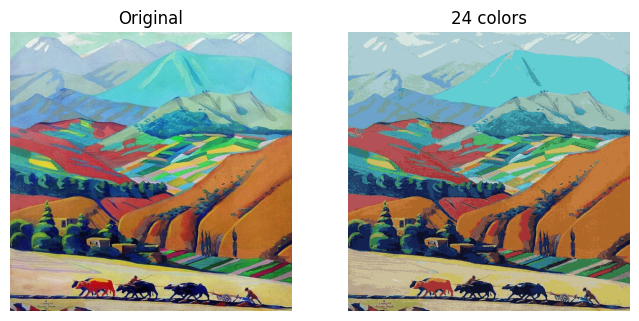

In [20]:
image_array = np.array(img)

compressed_24, kmeans_24 = compress_image(img, n_colors_input=24)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(compressed_24)
axes[1].set_title("24 colors")
axes[1].axis("off")
plt.show()

Mini-Batch K-Means

In [25]:
from sklearn.cluster import MiniBatchKMeans

In [29]:
def compress_image_minibatch(img, n_colors, batch_size):
    image_array = np.array(img)

    pixels = image_array.reshape(-1, 3).astype(np.float64)

    kmeans = MiniBatchKMeans(
        n_clusters=n_colors,
        batch_size=batch_size,
        random_state=42,
        n_init=3
    )

    labels = kmeans.fit_predict(pixels)
    compressed_pixels = kmeans.cluster_centers_[labels]

    compressed_image = (
        compressed_pixels
        .reshape(image_array.shape)
        .clip(0, 255)
        .astype(np.uint8)
    )

    return compressed_image, kmeans


/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lusine/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:2

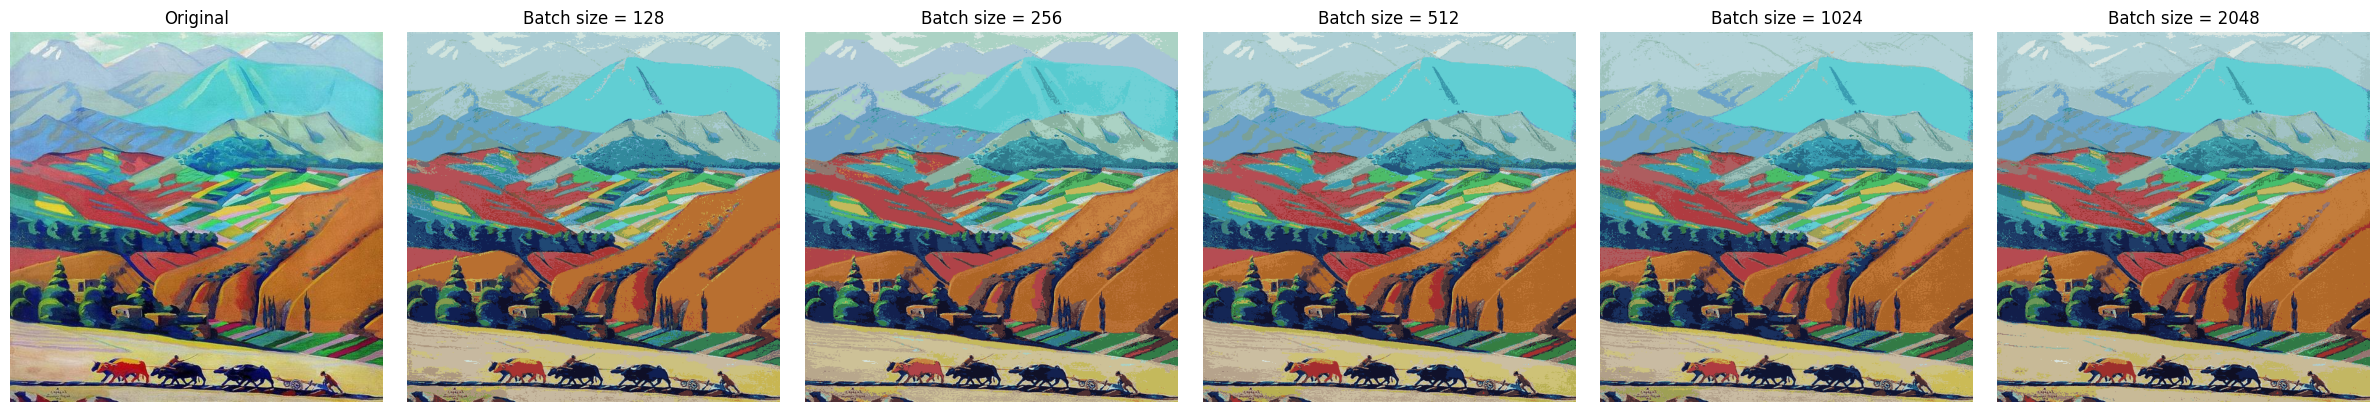

In [ ]:
image_array = np.array(img)

n_colors = 24
batch_sizes = [128, 256, 512, 1024, 2048]

fig, axes = plt.subplots(
    1,
    len(batch_sizes) + 1,
    figsize=(4 * (len(batch_sizes) + 1), 4)
)

axes[0].imshow(image_array)
axes[0].set_title("Original")
axes[0].axis("off")

for ax, batch_size in zip(axes[1:], batch_sizes):

    compressed, kmeans = compress_image_minibatch(
        img,
        n_colors=n_colors,
        batch_size=batch_size
    )

    ax.imshow(compressed)
    ax.set_title(f"Batch size = {batch_size}")
    ax.axis("off")

plt.tight_layout()
plt.show()